## 算符代数的一些工具

目前主要是费米子的算符代数，后续会添加玻色子算符代数的内容。

In [ ]:
import quante as qt
op = qt.generate.operas

builder = op.FermionBuilder()
builder += '-'*6 + '+'*6, list(range(1, 7))+list(range(1, 7)), 1.
ham = builder.build()
ham

FermionOper at 0x17e8b32edb0, 
|   -     -     -     -     -     -     +     +     +     +     +     +       coef. |
|-----------------------------------------------------------------------------------|
|   1     2     3     4     5     6     1     2     3     4     5     6       1.000 |

In [4]:
ham.normal_ordering()

FermionOper at 0x17e8b32ede0, 
|   I       coef. |   +     -       coef. |   +     +     -     -       coef. |
|-----------------|-----------------------|-----------------------------------|
|   0      -1.000 |   1     1       1.000 |   1     2     1     2       1.000 |
|                 |   2     2       1.000 |   1     3     1     3       1.000 |
|                 |   3     3       1.000 |   2     3     2     3       1.000 |
|                 |   4     4       1.000 |   1     4     1     4       1.000 |
|                 |   5     5       1.000 |   2     4     2     4       1.000 |
|                 |   6     6       1.000 |   3     4     3     4       1.000 |
|                                         |   1     5     1     5       1.000 |
|                                         |   2     5     2     5       1.000 |
|                                         |   3     5     3     5       1.000 |
|                                         |   4     5     4     5       1.000 |
|        

# 

In [5]:
# JW transformation
import quante as qt

op = qt.generate.operas
builder = op.SpinBuilder()
L = 10
J, γ = 1, 0.0
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

ham.jw_transfer()

FermionOper at 0x17e8e966870, 
|   +     -       coef. |
|-----------------------|
|   1     0      -0.500 |
|   0     1      -0.500 |
|   2     1      -0.500 |
|   1     2      -0.500 |
|   3     2      -0.500 |
|   2     3      -0.500 |
|   4     3      -0.500 |
|   3     4      -0.500 |
|   5     4      -0.500 |
|   4     5      -0.500 |
|   6     5      -0.500 |
|   5     6      -0.500 |
|   7     6      -0.500 |
|   6     7      -0.500 |
|   8     7      -0.500 |
|   7     8      -0.500 |
|   9     8      -0.500 |
|   8     9      -0.500 |

# Solve Model

## Hatano-Nelson model

10.1103/PhysRevX.13.021007

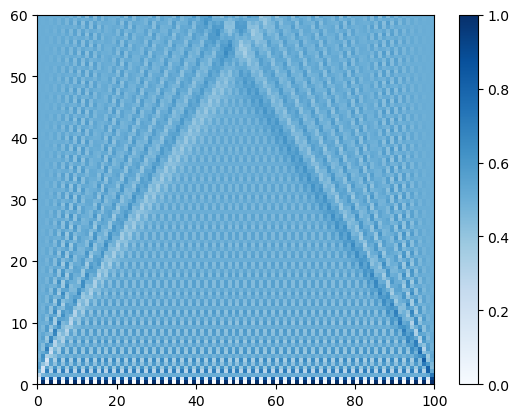

In [1]:
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.0
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

res = qt.solvable_models.free_fermion.free_fermion_measure_n(ham, '01'*(L//2), np.linspace(0, 60, 100))
import matplotlib.pyplot as plt
plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.colorbar()
